In [ ]:
## STANDARDIZED AND NORMALIZATION 
FEATURE SCALING TOPIC:


In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

df =pd.read_csv(r'C:\Users\Dhruv stark\Desktop\machine learning practice\wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['class label','Malic acid','Alchol']
df.head()

,class label,Malic acid,Alchol
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [9]:
df.columns=['class label','Malic acid','Alchol']

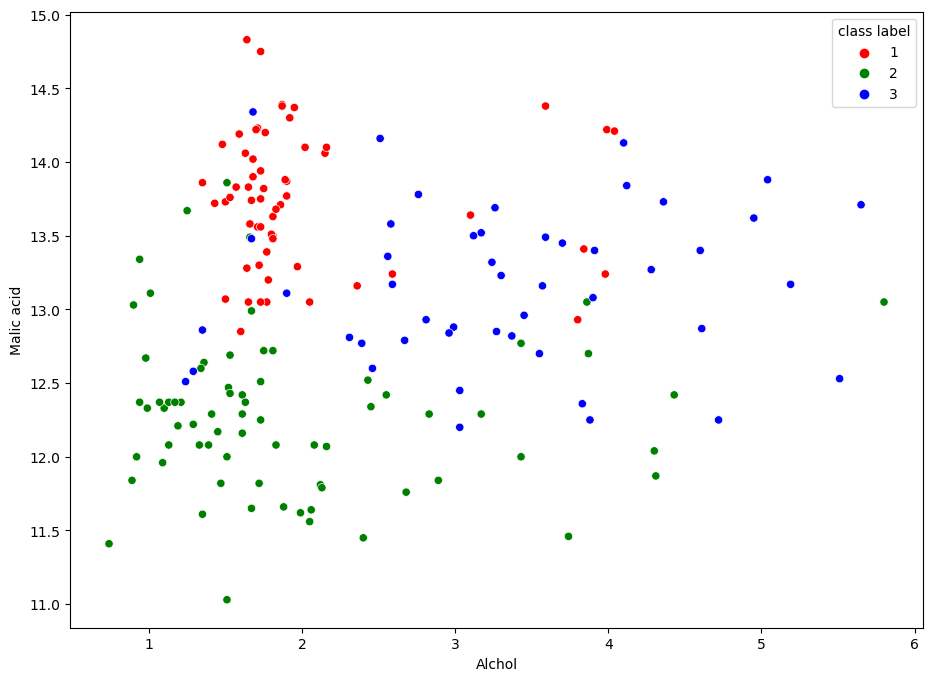

In [10]:
#scatterplot 

plt.figure(figsize=(11,8))

colour_dict = {1:'red', 2:'green', 3:'blue'}

sns.scatterplot(
    x=df['Alchol'],
    y=df['Malic acid'],
    hue=df['class label'],
    palette=colour_dict
)

plt.show()

In [11]:
import sklearn
print(sklearn.__version__)

1.8.0


In [12]:
from sklearn.model_selection import train_test_split 
x=df.drop('class label',axis=1)
y=df['class label']
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.3)

x_train.shape

(124, 2)

In [13]:
from sklearn.preprocessing import MinMaxScaler 
minmax = MinMaxScaler()


In [14]:
minmax.fit(x_train)
x_trans = minmax.transform(x_train)
x_tested = minmax.transform(x_test)

#HERE WE HAVE TO CONVERT BACK TO DATAFRAM BECOAUSE IT LOOSE COLUMNS IF WANT TO ANALYSIS AND EDA THE DATA THEN WE HAVE TO !!  

In [15]:
x_trained  = pd.DataFrame(x_trans,columns = x_train.columns)
y_trained  = pd.DataFrame(x_tested,columns = x_test.columns)
x_trained.columns


Index(['Malic acid', 'Alchol'], dtype='object')

In [58]:
x_trained.describe().T

,count,mean,std,min,25%,50%,75%,max
Malic acid,124.0,0.508765,0.221444,0.0,0.331579,0.503947,0.701316,1.0
Alchol,124.0,0.308143,0.224504,0.0,0.152749,0.205703,0.464358,1.0


In [ ]:
#comparing both before scaling and after scaling 

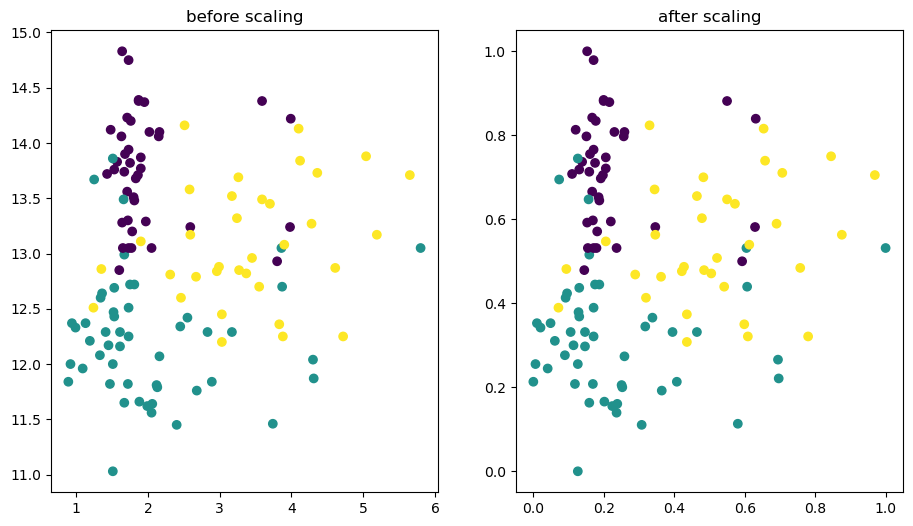

In [22]:
## how campare two atttribute in subplot 
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(11,6))
ax1.scatter(x_train['Alchol'],x_train['Malic acid'],c=y_train)
ax1.set_title('before scaling')
ax2.scatter(x_trained['Alchol'],x_trained['Malic acid'],c=y_train)
ax2.set_title('after scaling')
plt.show()

## FEATURE SCALING , ( MINMAXSCALING = NORMALIZATION ) , ROBUST AND STANDRADIZING

07:10
Why Scale Features — Plain English
The problem
Age       → values between 0 and 100
Income    → values between 0 and 10,000,000
Spending  → values between 0 and 500
Model sees Income number is 100,000x bigger than Age. So it treats Income as 100,000x more important — not because it actually is, just because the number is larger.

What scaling does
Brings all columns to the same range so no column dominates just because of its unit size.

After scaling:
Age     → -1.2 to +1.2
Income  → -1.2 to +1.2
Spending → -1.2 to +1.2

Now model treats all columns fairly
Models that NEED scaling
These models use distance or gradient calculations — large numbers break their math:

KNN          → measures distance between rows
SVM          → finds boundary between classes
KMeans       → measures distance to cluster centers
Neural Nets  → gradient descent breaks with large numbers
Logistic Regression → gradient based
Models that DON'T need scaling
Decision Tree   → splits on thresholds, scale irrelevant
Random Forest   → collection of trees, same reason
XGBoost         → tree based, doesn't care about scale
LightGBM        → tree based, same reason
Your notes say "few → Tree based AI" — exactly right.

Last point — scaling helps models train faster
Even when not strictly required, scaled data helps gradient-based models converge faster — meaning they reach a good solution in fewer steps, saving computation time.







In [12]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

df = pd.read_csv(r'C:\Users\Dhruv stark\Desktop\machine learning practice\Housing.csv')

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [7]:
df.columns 

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [8]:
# target price
#feature area', 'bedrooms', 'bathrooms', 'stories'

In [7]:
x = df.drop(columns=['mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'])
y=df['price']


x.head(3)


minmax = MinMaxScaler()
data_t =minmax.fit_transform(x)
xdata = pd.DataFrame(data_t,columns=x.columns)

xdata.describe().T


,count,mean,std,min,25%,50%,75%,max
price,545.0,0.261189,0.161943,0.0,0.145455,0.224242,0.345455,1.0
area,545.0,0.240587,0.149151,0.0,0.134021,0.202749,0.323711,1.0
bedrooms,545.0,0.393028,0.147613,0.0,0.200000,0.400000,0.400000,1.0
bathrooms,545.0,0.095413,0.167490,0.0,0.000000,0.000000,0.333333,1.0
stories,545.0,0.268502,0.289164,0.0,0.000000,0.333333,0.333333,1.0


In [ ]:
##When to Use Linear Scaling (MinMaxScaler) — Plain English

Use MinMaxScaler only when ALL three conditions are true:

Condition 1 — Data range stays stable over time
Age will always be 0–100 → stable ✅
Stock price today 500, tomorrow 50000 → unstable ❌
Your min and max values today should roughly be the same in future data too.

Condition 2 — No extreme outliers
Ages: 20, 25, 30, 28, 27 → no outliers ✅
Ages: 20, 25, 30, 28, 950 → extreme outlier ❌

One extreme outlier squeezes all normal values
into a tiny range like 0.02 to 0.03
MinMaxScaler becomes useless

Condition 3 — Data is spread roughly evenly across range
Good — uniform distribution:
Age histogram:
20s → ████
30s → ████
40s → ████
50s → ████
All bars roughly same height ✅

Bad — skewed distribution:
Sales histogram:
Low  → ████████████
Mid  → ████
High → █
Bars very uneven ❌ → use log transform first


Human Age satisfies all three:
Range stable    → always 0–120 ✅
No extreme outliers → rarely see age 500 ✅
Roughly uniform → people exist at all age ranges ✅
→ MinMaxScaler works well

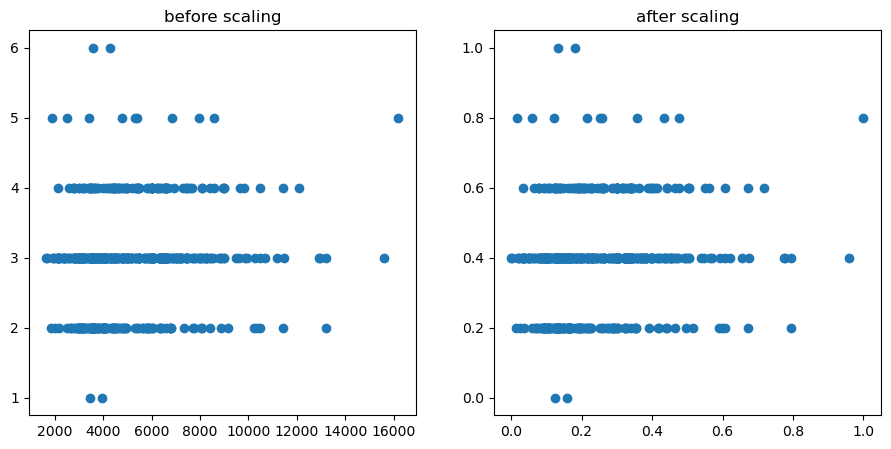

In [39]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(11,5))
ax1.scatter(x["area"],x["bedrooms"])
ax1.set_title('before scaling')
ax2.scatter(xdata["area"],xdata["bedrooms"])
ax2.set_title('after scaling')
plt.show()

In [ ]:
##STANDARDSCALING 

In [47]:
standard = StandardScaler()

xtour = standard.fit_transform(x)
x_std  = pd.DataFrame(xtour,columns = x.columns)

x_std.head()

,price,area,bedrooms,bathrooms,stories
0,4.566365,1.046726,1.403419,1.421812,1.378217
1,4.004484,1.757010,1.403419,5.405809,2.532024
2,4.004484,2.218232,0.047278,1.421812,0.224410
3,3.985755,1.083624,1.403419,1.421812,0.224410
4,3.554979,1.046726,1.403419,-0.570187,0.224410


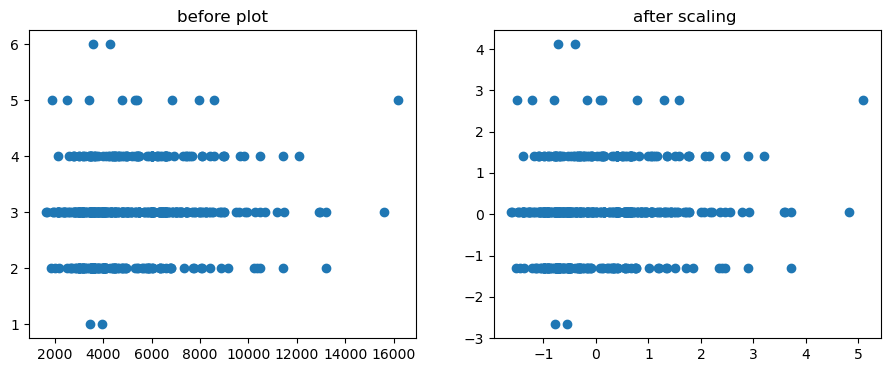

In [50]:
fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize=(11,4))
ax1.scatter(x["area"],x["bedrooms"])
ax1.set_title("before plot")
ax2.scatter(x_std["area"],x_std["bedrooms"])
ax2.set_title("after scaling ")
plt.show()

In [54]:
#ROBUST SCALING 


rob = RobustScaler()
x_rob = rob.fit_transform(x)
x_robust = pd.DataFrame(x_rob,columns = x.columns)

x_robust.head()

,price,area,bedrooms,bathrooms,stories
0,3.878788,1.021739,1.0,1.0,1.0
1,3.424242,1.579710,1.0,3.0,2.0
2,3.424242,1.942029,0.0,1.0,0.0
3,3.409091,1.050725,1.0,1.0,0.0
4,3.060606,1.021739,1.0,0.0,0.0


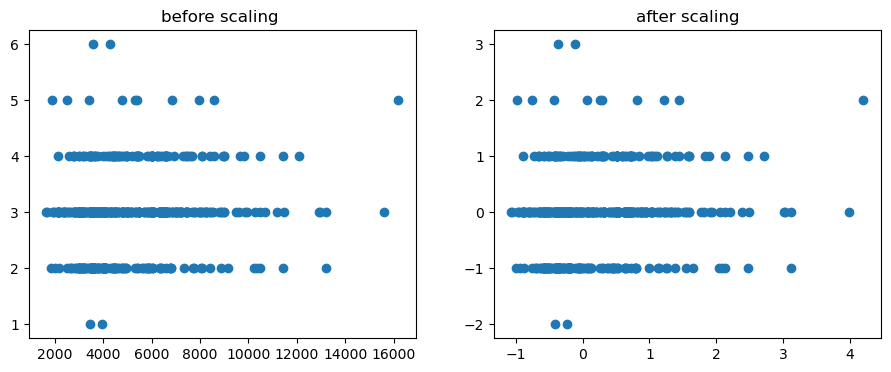

In [55]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(11,4))
ax1.scatter(x["area"],x["bedrooms"])
ax1.set_title("before scaling ")
ax2.scatter(x_robust["area"],x_robust["bedrooms"])
ax2.set_title("after scaling")
plt.show()